In [ ]:
import pandas as pd
import os
import tifffile
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2


In [ ]:
# Default image size
default_size = (128, 128)

# Directory containing the images
image_dir = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30'

# Find all image files starting with "imagem_segmentada_"
image_files = [filename for filename in os.listdir(image_dir) if filename.startswith('imagem_segmentada_')]

# List to store the channel data of all valid TIFF images
channel_data = []

# Load images, resize, and extract channel data
for filename in image_files:
    # Load image
    image_path = os.path.join(image_dir, filename)
    try:
        image = tifffile.imread(image_path)
        resized_image = cv2.resize(image, default_size)
        channel_data.extend(resized_image.transpose((2, 0, 1)))
    except tifffile.TiffFileError:
        print(f"Skipping file: {filename}. Not a valid TIFF file.")
    except cv2.error:
        print(f"Skipping file: {filename}. Error occurred during image resizing.")

# Stack channel data into a single array
channel_data = np.stack(channel_data, axis=-1)

# Calculate mean correlation matrix
mean_corr_matrix = np.corrcoef(channel_data.reshape(-1, channel_data.shape[-1]), rowvar=False)

# Create a heatmap chart for the correlation matrix
sns.heatmap(mean_corr_matrix, cmap='RdYlBu_r', annot=True, fmt='.2f')

# Display the chart
plt.title('Mean Correlation Matrix')
plt.show()

Skipping file: imagem_segmentada_4_0830_LARGO1_AVARAGE.tif.enp. Not a valid TIFF file.


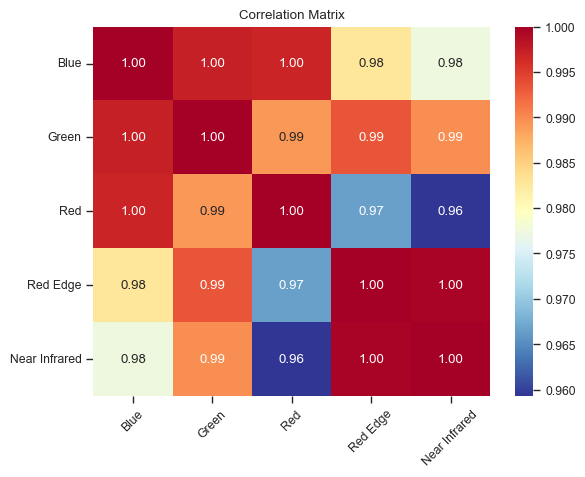

In [25]:
import tifffile
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import cv2


# Default image size
default_size = (128, 128)

# Directory containing the images
image_dirs = ['dir1', 'dir2', 'dir3']

image_dir = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30'

# Find all image files starting with "imagem_segmentada_"
image_files = [filename for filename in os.listdir(image_dir) if filename.startswith('imagem_segmentada_')]

# Initialize variables for mean calculation
mean_image = None
num_images = 0

# Iterate over each directory
for image_dir in image_dirs:
    # Find all image files starting with "imagem_segmentada_"
    image_files = [filename for filename in os.listdir(image_dir) if filename.startswith('imagem_segmentada_')]

    # Load and resize the images while calculating the mean
    for image_file in image_files:
        image_path = os.path.join(image_dir, image_file)
        try:
            image = tifffile.imread(image_path)
            resized_image = cv2.resize(image, default_size)
            resized_image = resized_image.astype(np.float64)  # Convert to float64

            num_images += 1

            if mean_image is None:
                mean_image = resized_image
            else:
                mean_image = mean_image.astype(np.float64)  # Convert mean_image to float64
                mean_image += (resized_image - mean_image) / num_images

        except tifffile.TiffFileError:
            print(f"Skipping file: {image_file}. Not a valid TIFF file.")
        except cv2.error:
            print(f"Skipping file: {image_file}. Error occurred during image resizing.")

# Reshape the mean image to column vectors
reshaped_mean_image = mean_image.reshape(-1, mean_image.shape[2])

# Calculate correlation matrix
corr_matrix = np.corrcoef(reshaped_mean_image, rowvar=False)

# Set Seaborn style
sns.set_style("ticks")
sns.set_context("paper")

# Create a heatmap chart for the correlation matrix
sns.heatmap(corr_matrix, cmap='RdYlBu_r', annot=True, fmt='.2f')

# Set the x-axis and y-axis labels
channel_names = ["Blue", "Green", "Red", "Red Edge", "Near Infrared"]
plt.xticks(np.arange(len(channel_names)) + 0.5, channel_names, rotation=45)
plt.yticks(np.arange(len(channel_names)) + 0.5, channel_names, rotation=0)

# Display the chart
plt.title('Correlation Matrix')
plt.show()

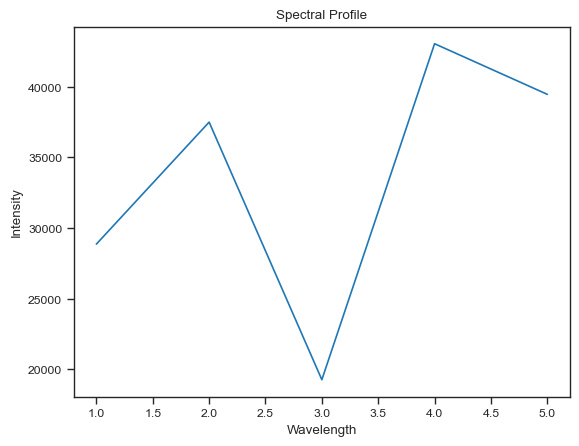

In [8]:
# Select a pixel or region of interest (ROI)
x = 50  # X-coordinate of the pixel/ROI
y = 50  # Y-coordinate of the pixel/ROI

# Extract the spectral profile at the selected pixel/ROI
spectral_profile = resized_image[y, x, :]

# Plot the spectral profile
wavelengths = np.arange(1, spectral_profile.shape[0] + 1)  # Assuming wavelengths start from 1
plt.plot(wavelengths, spectral_profile)
plt.xlabel('Wavelength')
plt.ylabel('Intensity')
plt.title('Spectral Profile')
plt.show()

In [23]:
import importlib 
importlib.reload(utils) 
import utils as utils

file = r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\LARGO_1_1026_ALLN_QUAC"
shp_file = r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\PLOTBOUNDARIES\PLOTBOUNDARIES_PROJECT.shp"
output_folder = r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-26"

utils.split_plots(file, shp_file, output_folder, '1026', 'HEALTH_STA')

100%|██████████| 300/300 [00:46<00:00,  6.48it/s]
